# Validate Adaptive Mask

This notebook is designed for Google Colab to validate the adaptive mask against standard atlases.
It performs the following steps:
1. Mounts Google Drive.
2. Imports necessary libraries (`nilearn`, `nibabel`, `numpy`, `matplotlib`).
3. Loads the adaptive mask from Google Drive.
4. Fetches a standard atlas (e.g., Harvard-Oxford).
5. Calculates the Dice coefficient spatial overlap between the mask and the atlas.
6. Plots the mask overlay for visual inspection.

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Install and import necessary libraries
!pip install nilearn nibabel matplotlib numpy -q

import nilearn
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets
from nilearn import plotting
from nilearn.image import resample_to_img

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 63.9 MB/s eta 0:00:00


In [4]:
import numpy as np
import nibabel as nib
from nilearn import datasets, image

n_features = 308546

print(f"Attempting to reconstruct mask from GM probabilities (Force Top {n_features})...")

# Load GM Prob
dataset = datasets.fetch_icbm152_2009()
gm_prob = image.load_img(dataset.gm)

# Through the original code's search range, it probably found a best resolution.
gm_mask = datasets.fetch_icbm152_brain_gm_mask(threshold=0.2)
base_affine = gm_mask.affine

best_diff = float('inf')
best_res = -1
search_range = np.arange(1.0, 3.1, 0.1)

for res in search_range:
    new_affine = base_affine.copy()
    new_affine[:3, :3] *= res
    resampled_temp = image.resample_img(
        gm_mask,
        target_affine=new_affine,
        interpolation='nearest',
        copy_header=True,
        force_resample=True
    )
    count = np.sum(resampled_temp.get_fdata() != 0)
    diff = abs(count - n_features)
    if diff < best_diff:
        best_diff = diff
        best_res = res

print(f"Best resolution found: {best_res:.3f}mm")

# Now reconstruct the probability mask
new_affine = gm_prob.affine.copy()
new_affine[:3, :3] *= best_res

resampled_prob = image.resample_img(
    gm_prob,
    target_affine=new_affine,
    interpolation='linear',
    force_resample=True,
    copy_header=True
)

prob_data = resampled_prob.get_fdata()
flat_prob = prob_data.ravel()

top_k_indices = np.argsort(flat_prob)[-n_features:]

mask_data = np.zeros_like(flat_prob, dtype=np.int8)
mask_data[top_k_indices] = 1
mask_data = mask_data.reshape(prob_data.shape)

matched_mask = image.new_img_like(resampled_prob, mask_data)

output_path = "adaptive_mask.nii.gz"
matched_mask.to_filename(output_path)
print(f"Successfully saved mask with {np.sum(mask_data)} voxels to {output_path}")

Attempting to reconstruct mask from GM probabilities (Force Top 308546)...


[fetch_icbm152_2009] Added README.md to /root/nilearn_data

[fetch_icbm152_2009] Dataset created in /root/nilearn_data/icbm152_2009

[fetch_icbm152_2009] Downloading data from https://osf.io/7pj92/download ...

[fetch_icbm152_2009]  ...done. (2 seconds, 0 min)

[fetch_icbm152_2009] Extracting data from 
/root/nilearn_data/icbm152_2009/6986d62a4af09641f8625dc5757f4796/download...

[fetch_icbm152_2009] .. done.

[fetch_icbm152_brain_gm_mask] Dataset found in /root/nilearn_data/icbm152_2009

Best resolution found: 1.700mm
Successfully saved mask with 308546 voxels to adaptive_mask.nii.gz


In [5]:
# Load the adaptive mask from Google Drive
# Replace this placeholder path with the actual path to your adaptive mask file
adaptive_mask_path = '/content/adaptive_mask.nii.gz'

try:
    adaptive_mask_img = nib.load(adaptive_mask_path)
    print(f"Successfully loaded adaptive mask from {adaptive_mask_path}")
except FileNotFoundError:
    print(f"File not found at {adaptive_mask_path}. Please check the path.")

Successfully loaded adaptive mask from /content/adaptive_mask.nii.gz


In [7]:
# Fetch a standard atlas (Harvard-Oxford cortical atlas)
ho_atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_img = ho_atlas.maps

print(f"Successfully loaded Harvard-Oxford atlas from {ho_atlas.maps}")

[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

Successfully loaded Harvard-Oxford atlas from 
<class 'nibabel.nifti1.Nifti1Image'>
data shape (91, 109, 91)
affine:
[[   2.    0.    0.  -90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3  91 109  91   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 2. 2. 2. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 48.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'FSL3.3'
aux_file        : b

In [8]:
# Resample the atlas to match the dimensions and affine of the adaptive mask
resampled_atlas_img = resample_to_img(atlas_img, adaptive_mask_img, interpolation='nearest')

# Binarize both images for Dice coefficient calculation
adaptive_mask_data = adaptive_mask_img.get_fdata() > 0
atlas_data = resampled_atlas_img.get_fdata() > 0

# Calculate Dice coefficient spatial overlap
intersection = np.logical_and(adaptive_mask_data, atlas_data).sum()
volume_sum = adaptive_mask_data.sum() + atlas_data.sum()

if volume_sum == 0:
    dice_coefficient = 1.0
else:
    dice_coefficient = 2.0 * intersection / volume_sum

print(f"Dice Coefficient (Spatial Overlap): {dice_coefficient:.4f}")

Dice Coefficient (Spatial Overlap): 0.7529


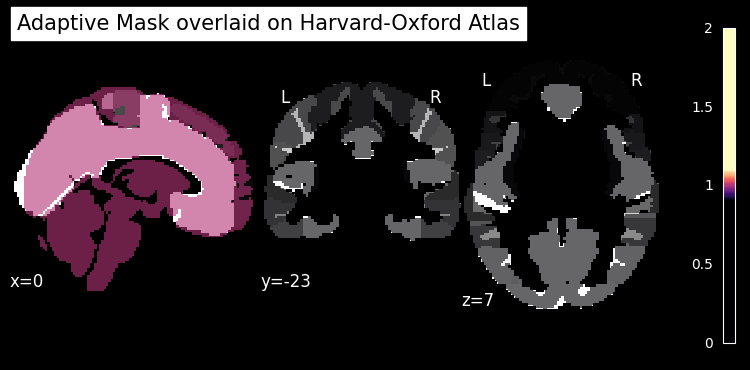

In [9]:
# Plot the mask overlay
display = plotting.plot_roi(
    roi_img=adaptive_mask_img,
    bg_img=atlas_filename,
    title="Adaptive Mask overlaid on Harvard-Oxford Atlas",
    cmap="magma",
    alpha=0.6,
    dim=-1,
    draw_cross=False
)
plotting.show()